In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# 导入你的三个核心基准算法
import backward
import backward_adp
from ppo import RelaxedMultiAssetEnv

# 设置通用的可视化风格
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [8]:
print("=== 测试 1: 无风险套利 (Arbitrage Test) ===")
# 设定一个极具吸引力的资产: 预期收益 50%, 方差极小
test1_n = 1
test1_T = 3
test1_r = 0.03
test1_A = 0.5
test1_ak = [0.50]
test1_sk = [0.0001]
test1_lev = 2.0
test1_p_init = [1.0, 0.0]

# ---------------------------------------------------------
# 1. 运行 Grid DP
# ---------------------------------------------------------
print("\n[1. 计算 Grid DP...]")
v_grids_1, policy_1, config_dp_1 = backward.solve_dp(
    n=test1_n, T=test1_T, r=test1_r, A=test1_A,
    a_k=test1_ak, s_k=test1_sk,
    leverage_factor=test1_lev, p_init=test1_p_init
)

# 找到 W≈1 和 p_risky=0 对应的网格索引
wi_mid_1 = int(np.argmin(np.abs(config_dp_1['w_grid'] - 1.0)))
pg_1 = config_dp_1['p_single_grid']
p0_idx_1 = int(np.argmin(np.abs(pg_1 - 0.0)))

W_val_1 = config_dp_1['w_grid'][wi_mid_1]
action_dp_1 = policy_1[0][(wi_mid_1, p0_idx_1)]
dp1_risky = np.array([0.0]) + action_dp_1
dp1_cash = 1.0 - dp1_risky.sum()
print(f"👉 Grid DP 调仓后 (W={W_val_1:.2f})：现金={dp1_cash:.2f}，风险资产={dp1_risky[0]:.2f}")

# ---------------------------------------------------------
# 2. 运行 ADP
# ---------------------------------------------------------
print("\n[2. 计算 ADP...]")
import torch
v_nets_1, policy_nets_1, config_adp_1 = backward_adp.solve_dp(
    n=test1_n, T=test1_T, r=test1_r, A=test1_A,
    a_k=test1_ak, s_k=test1_sk,
    leverage_factor=test1_lev, p_init=test1_p_init,
    hidden_size=128, n_train=3000, epochs=200, lr=1e-3
)

state_adp_1 = torch.tensor([[1.0, 0.0]], dtype=torch.float32)  # [W, p1]
with torch.no_grad():
    action_adp_1 = policy_nets_1[0](state_adp_1).squeeze(0).numpy() * config_adp_1['action_max']
adp1_risky = np.array([0.0]) + action_adp_1
adp1_cash = 1.0 - adp1_risky.sum()
print(f"👉 ADP 调仓后：现金={adp1_cash:.2f}，风险资产={adp1_risky[0]:.2f}")

# ---------------------------------------------------------
# 3. 训练 PPO
# ---------------------------------------------------------
print("\n[3. 训练 PPO...]")
env_arb = RelaxedMultiAssetEnv(
    n=test1_n, T=test1_T, r=test1_r, A=test1_A,
    a_k=test1_ak, s_k=test1_sk,
    leverage_factor=test1_lev, p_init=test1_p_init
)
model_arb = PPO("MlpPolicy", env_arb, verbose=0, learning_rate=0.001)
model_arb.learn(total_timesteps=100000)

obs, _ = env_arb.reset()
action, _ = model_arb.predict(obs, deterministic=True)
obs, reward, done, truncated, info = env_arb.step(action)

ppo1_cash = info['rebalanced_cash']
ppo1_risky = info['rebalanced_risky']
print(f"👉 PPO 调仓后：现金={ppo1_cash:.2f}，风险资产={ppo1_risky[0]:.2f}")

# ---------------------------------------------------------
# 汇总对比
# ---------------------------------------------------------
print("\n" + "="*60)
print("汇总对比 (近似无风险套利, 预期: 尽量多买风险资产)")
print("="*60)
print(f"  Grid DP:  现金={dp1_cash:.2f}, 风险资产={dp1_risky[0]:.2f}")
print(f"  ADP:      现金={adp1_cash:.2f}, 风险资产={adp1_risky[0]:.2f}")
print(f"  PPO:      现金={ppo1_cash:.2f}, 风险资产={ppo1_risky[0]:.2f}")
print("\n🎯 预期结果: 三种方法都应该尽可能多地买入风险资产 (受10%换手率限制，最多买0.10)。")

=== 测试 1: 无风险套利 (Arbitrage Test) ===

[1. 计算 Grid DP...]
Setup: n=1, T=3, r=0.03, A=0.5
  Mean returns:   [np.float64(0.5)]
  Excess returns: [np.float64(0.47)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 9 pts in [-0.5, 1.5], step=0.25
  Prop combos: 9
  Actions: 5 feasible
  Quadrature: 5^1 = 5 points

Backward Induction
  t=2: 135 states, 0.0s
  t=1: 135 states, 0.0s
  t=0: 135 states, 0.0s

Total solve time: 0.0s
👉 Grid DP 调仓后 (W=1.04)：现金=0.90，风险资产=0.10

[2. 计算 ADP...]
ADP Setup: n=1, T=3, r=0.03, A=0.5
  Mean returns:   [np.float64(0.5)]
  Excess returns: [np.float64(0.47)]
  Training samples per step: 3000
  Actions: 5 feasible
  Quadrature: 5^1 = 5 points
  NN: hidden_size=128, epochs=200, lr=0.001

Backward Induction (ADP)
  t=2: 3000 samples, v_loss=0.003930, pi_loss=0.000083, 1.5s
  t=1: 3000 samples, v_loss=0.000125, pi_loss=0.000201, 2.5s
  t=0: 3000 samples, v_loss=0.000000, pi_loss=0.000284, 2.4s

Total solve time: 6.4s
👉 ADP 调仓后：现金=0.90，风险资产=0.10

[3. 训练 PPO...]
👉 

In [9]:
print("=== 测试 2: 极度风险厌恶 (Extreme Risk Aversion) ===")
# 设定极度害怕风险的 A=50.0
test2_A = 50.0 
test2_ak = [0.08, 0.06, 0.10]
test2_sk = [0.02, 0.015, 0.04]
test2_lev = 2.0
test2_p_init = [1.0, 0.0, 0.0, 0.0]  # 全仓现金

# ---------------------------------------------------------
# 1. 运行传统 Grid DP (绝对真实的数学标尺)
# ---------------------------------------------------------
print("\n[1. 计算 Grid DP...]")
v_grids, policy, config_dp = backward.solve_dp(
    n=3, T=2, r=0.03, A=test2_A, a_k=test2_ak, s_k=test2_sk,
    prop_step=0.25, leverage_factor=test2_lev, p_init=test2_p_init
)

# 找到 W≈1 和 p_risky=0 对应的网格索引
wi_mid = int(np.argmin(np.abs(config_dp['w_grid'] - 1.0)))
pg = config_dp['p_single_grid']
p0_idx = int(np.argmin(np.abs(pg - 0.0)))  # 全仓现金 → risky=0

W_val = config_dp['w_grid'][wi_mid]
action_at_cash = policy[0][(wi_mid, p0_idx, p0_idx, p0_idx)]
dp_risky = np.array([0.0, 0.0, 0.0]) + action_at_cash
dp_cash = 1.0 - dp_risky.sum()
print(f"👉 Grid DP 调仓后 (W={W_val:.2f})：现金={dp_cash:.2f}，"
      f"风险资产=[{dp_risky[0]:.2f}, {dp_risky[1]:.2f}, {dp_risky[2]:.2f}]")

# ---------------------------------------------------------
# 2. 运行 ADP (Neural Network 近似 DP)
# ---------------------------------------------------------
print("\n[2. 计算 ADP...]")
v_nets, policy_nets, config_adp = backward_adp.solve_dp(
    n=3, T=2, r=0.03, A=test2_A, a_k=test2_ak, s_k=test2_sk,
    leverage_factor=test2_lev, p_init=test2_p_init,
    hidden_size=128, n_train=3000, epochs=200, lr=1e-3
)

import torch
state_adp = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)  # [W, p1, p2, p3]
with torch.no_grad():
    action_adp = policy_nets[0](state_adp).squeeze(0).numpy() * config_adp['action_max']
adp_risky = np.array([0.0, 0.0, 0.0]) + action_adp
adp_cash = 1.0 - adp_risky.sum()
print(f"👉 ADP 调仓后：现金={adp_cash:.2f}，"
      f"风险资产=[{adp_risky[0]:.2f}, {adp_risky[1]:.2f}, {adp_risky[2]:.2f}]")

# ---------------------------------------------------------
# 3. 运行 PPO
# ---------------------------------------------------------
print("\n[3. 训练 PPO...]")
env_scared = RelaxedMultiAssetEnv(
    n=3, T=2, r=0.03, A=test2_A, a_k=test2_ak, s_k=test2_sk, 
    leverage_factor=test2_lev, p_init=test2_p_init
)
model_scared = PPO("MlpPolicy", env_scared, verbose=0, learning_rate=0.001)
model_scared.learn(total_timesteps=150000) 

obs, _ = env_scared.reset()
action, _ = model_scared.predict(obs, deterministic=True)
obs, reward, done, truncated, info = env_scared.step(action)

ppo_cash = info['rebalanced_cash']
ppo_risky = info['rebalanced_risky']
print(f"👉 PPO 调仓后：现金={ppo_cash:.2f}，"
      f"风险资产=[{ppo_risky[0]:.2f}, {ppo_risky[1]:.2f}, {ppo_risky[2]:.2f}]")

# ---------------------------------------------------------
# 汇总对比
# ---------------------------------------------------------
print("\n" + "="*60)
print("汇总对比 (A=50, 预期: 全部接近 0)")
print("="*60)
print(f"  Grid DP:  现金={dp_cash:.2f}, 风险=[{dp_risky[0]:.2f}, {dp_risky[1]:.2f}, {dp_risky[2]:.2f}]")
print(f"  ADP:      现金={adp_cash:.2f}, 风险=[{adp_risky[0]:.2f}, {adp_risky[1]:.2f}, {adp_risky[2]:.2f}]")
print(f"  PPO:      现金={ppo_cash:.2f}, 风险=[{ppo_risky[0]:.2f}, {ppo_risky[1]:.2f}, {ppo_risky[2]:.2f}]")
print("\n🎯 预期结果: 三种方法的风险资产买入量都应该全是 0 (或者极其接近 0)。")

=== 测试 2: 极度风险厌恶 (Extreme Risk Aversion) ===

[1. 计算 Grid DP...]
Setup: n=3, T=2, r=0.03, A=50.0
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 9 pts in [-0.5, 1.5], step=0.25
  Prop combos: 729
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=1: 4,095 states, 6.2s
  t=0: 4,095 states, 6.1s

Total solve time: 12.3s
👉 Grid DP 调仓后 (W=1.04)：现金=1.00，风险资产=[0.00, 0.00, 0.00]

[2. 计算 ADP...]
ADP Setup: n=3, T=2, r=0.03, A=50.0
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Training samples per step: 3000
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points
  NN: hidden_size=128, epochs=200, lr=0.001

Backward Induction (ADP)
  t=1: 3000 samples, v_loss=0.000001, pi_loss=0.000000, 5.2s
  t=0: 3000 samples, v_loss=0.00000

In [10]:
print("=== 测试 3: 单资产跨算法交叉验证 (1D Cross-Validation) ===")
val_n = 1
val_T = 5
val_r = 0.03
val_ak = [0.10]  # 预期收益 10%
val_sk = [0.04]  # 方差 0.04
val_A = 0.5      # 恢复正常的风险厌恶
val_lev = 2.0
val_p_init = [1.0, 0.0]  # 全仓现金
val_action_max = 0.10     # 匹配 homework 10% 换手率限制
val_max_turnover = 0.10
val_episodes = 2000

# Pre-generate shared market returns so all methods face identical scenarios
shared_rng = np.random.RandomState(42)
shared_returns = shared_rng.normal(
    val_ak, np.sqrt(val_sk), size=(val_episodes, val_T, val_n)
)

print("\n[1. 运行 Grid DP (Ground Truth) ...]")
v_grids, policy, config_dp = backward.solve_dp(
    n=val_n, T=val_T, r=val_r, A=val_A, a_k=val_ak, s_k=val_sk,
    leverage_factor=val_lev, p_init=val_p_init,
    action_max=val_action_max, max_turnover=val_max_turnover,
    wealth_points=50, wealth_min=0.05, wealth_max=5.0,
    prop_step=0.05
)
res_dp = backward.simulate_dp(v_grids, policy, config_dp,
                               num_episodes=val_episodes, verbose=False, returns=shared_returns)
dp_u = np.mean(res_dp['utilities'])
print(f"👉 Grid DP 平均效用: {dp_u:.5f}")

print("\n[2. 运行 Approximate DP (Neural Network) ...]")
v_nets, policy_nets, config_adp = backward_adp.solve_dp(
    n=val_n, T=val_T, r=val_r, A=val_A, a_k=val_ak, s_k=val_sk,
    leverage_factor=val_lev, p_init=val_p_init,
    action_max=val_action_max, max_turnover=val_max_turnover,
    n_train=5000, epochs=100, lr=1e-3
)
res_adp = backward_adp.simulate_dp(v_nets, policy_nets, config_adp,
                                    num_episodes=val_episodes, verbose=False, returns=shared_returns)
adp_u = np.mean(res_adp['utilities'])
print(f"👉 ADP 平均效用:     {adp_u:.5f}")

print("\n[3. 运行 PPO (Reinforcement Learning) ...]")
env_val = RelaxedMultiAssetEnv(
    n=val_n, T=val_T, r=val_r, A=val_A, a_k=val_ak, s_k=val_sk,
    leverage_factor=val_lev, p_init=val_p_init,
    action_max=val_action_max, max_turnover=val_max_turnover
)
model_val = PPO("MlpPolicy", env_val, verbose=0, learning_rate=0.001)
model_val.learn(total_timesteps=200000)

# PPO simulation uses the same shared returns
ppo_utilities = []
ppo_wealth_paths = np.zeros((val_episodes, val_T + 1))
ppo_final_props = []

for ep in range(val_episodes):
    obs, _ = env_val.reset()
    ppo_wealth_paths[ep, 0] = 1.0
    done = False
    t_step = 0
    while not done:
        action, _ = model_val.predict(obs, deterministic=True)
        env_val._shared_return = shared_returns[ep, t_step]
        obs, reward, done, _, info = env_val.step(action)
        ppo_wealth_paths[ep, t_step + 1] = env_val.wealth
        if done:
            ppo_final_props.append(
                np.concatenate([[info['rebalanced_cash']], info['rebalanced_risky']])
            )
        t_step += 1
    ppo_utilities.append(reward)

ppo_u = np.mean(ppo_utilities)
ppo_final_props = np.array(ppo_final_props)
print(f"👉 PPO 平均效用:     {ppo_u:.5f}")

print(f"\n============================================================")
print(f"🏆 最终得分对比 (越接近 DP 越好):")
print(f"  Grid DP (绝对标尺): {dp_u:.5f}")
print(f"  ADP (神经网络近似): {adp_u:.5f}")
print(f"  PPO (强化学习):     {ppo_u:.5f}")
print(f"============================================================")

=== 测试 3: 单资产跨算法交叉验证 (1D Cross-Validation) ===

[1. 运行 Grid DP (Ground Truth) ...]
Setup: n=1, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.1)]
  Excess returns: [np.float64(0.07)]
  Wealth grid: 50 pts in [0.05, 5.0]
  Prop grid: 41 pts in [-0.5, 1.5], step=0.05
  Prop combos: 41
  Actions: 5 feasible
  Quadrature: 5^1 = 5 points

Backward Induction
  t=4: 2,050 states, 0.1s
  t=3: 2,050 states, 0.1s
  t=2: 2,050 states, 0.1s
  t=1: 2,050 states, 0.1s
  t=0: 2,050 states, 0.1s

Total solve time: 0.4s
👉 Grid DP 平均效用: 0.94523

[2. 运行 Approximate DP (Neural Network) ...]
ADP Setup: n=1, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.1)]
  Excess returns: [np.float64(0.07)]
  Training samples per step: 5000
  Actions: 5 feasible
  Quadrature: 5^1 = 5 points
  NN: hidden_size=128, epochs=100, lr=0.001

Backward Induction (ADP)
  t=4: 5000 samples, v_loss=0.308601, pi_loss=0.001606, 1.7s
  t=3: 5000 samples, v_loss=0.236946, pi_loss=0.000847, 2.7s
  t=2: 5000 samples, v_loss=0.006

Risk-Return Tradeoff (same market returns for all methods)
Method             E[W]     Std[W]    E[U(W)]
------------------------------------------
Grid DP         1.28941    0.19951    0.94523
ADP             1.28687    0.19575    0.94408
PPO             1.28941    0.19951    0.94523


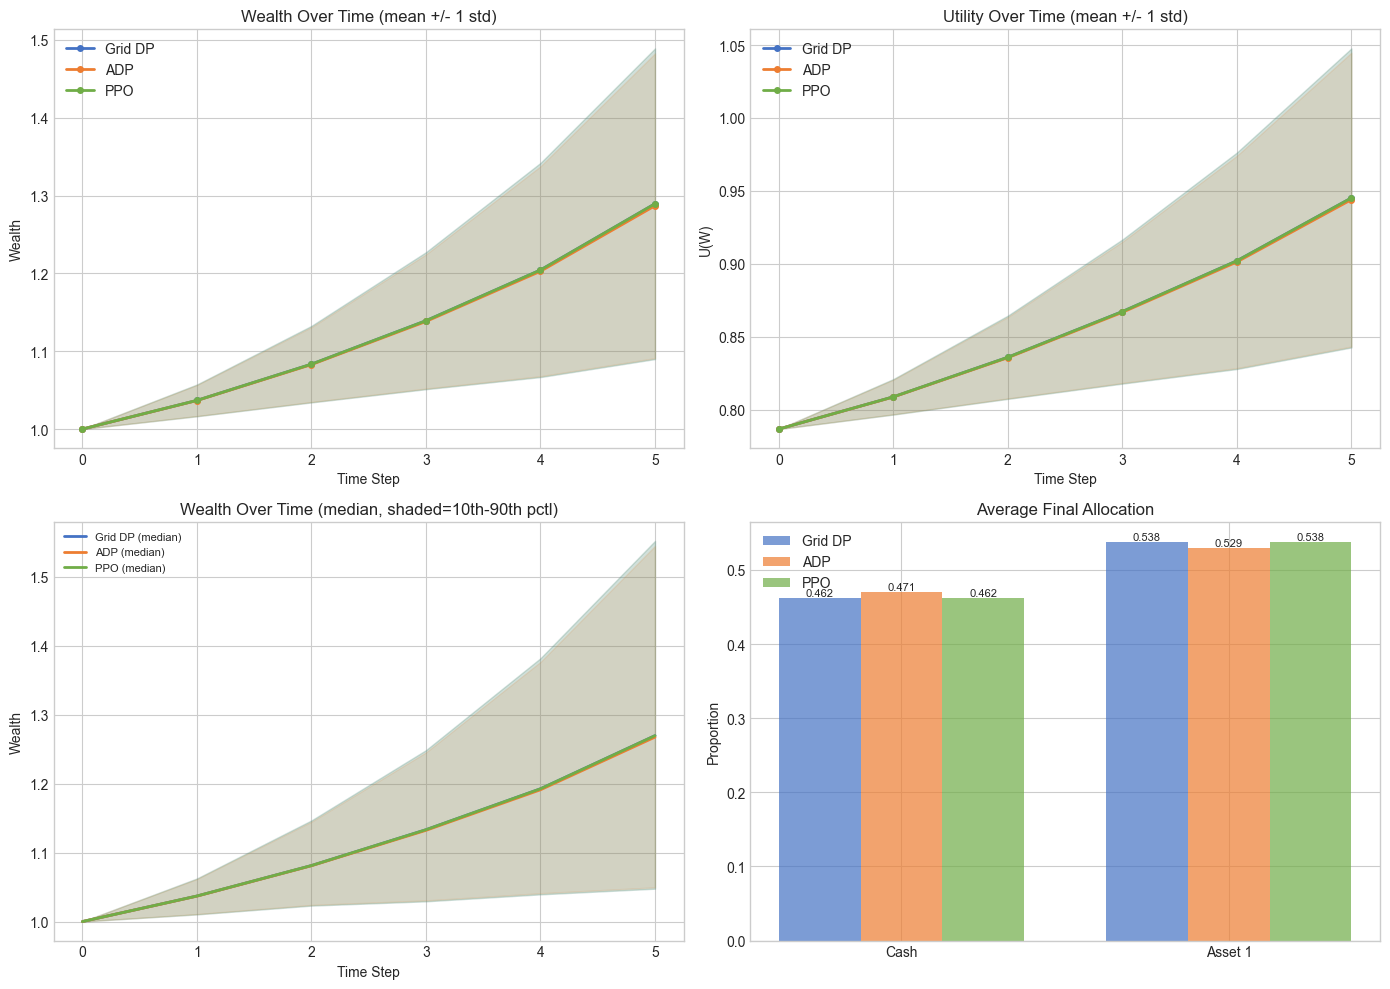

In [11]:
# ============================================================
# Plots (2x2) — all data already collected in test 3 cell
# ============================================================
ppo_terminal = ppo_wealth_paths[:, -1]

# Compute utility at every time step: U(W_t)
utility_fn = lambda W: (1.0 - np.exp(-val_A * np.clip(W, -20, 100))) / val_A
dp_util_paths = utility_fn(res_dp['wealth_paths'])
adp_util_paths = utility_fn(res_adp['wealth_paths'])
ppo_util_paths = utility_fn(ppo_wealth_paths)

# Statistics
print("=" * 70)
print("Risk-Return Tradeoff (same market returns for all methods)")
print("=" * 70)
print(f"{'Method':<12} {'E[W]':>10} {'Std[W]':>10} {'E[U(W)]':>10}")
print("-" * 42)
for name, tw, up in [
    ("Grid DP", res_dp['terminal_wealths'], dp_util_paths[:, -1]),
    ("ADP",     res_adp['terminal_wealths'], adp_util_paths[:, -1]),
    ("PPO",     ppo_terminal,                ppo_util_paths[:, -1]),
]:
    print(f"{name:<12} {np.mean(tw):>10.5f} {np.std(tw):>10.5f} {np.mean(up):>10.5f}")

# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
time_steps = np.arange(val_T + 1)
colors = {'dp': '#4472C4', 'adp': '#ED7D31', 'ppo': '#70AD47'}
labels = {'dp': 'Grid DP', 'adp': 'ADP', 'ppo': 'PPO'}
all_wp = {'dp': res_dp['wealth_paths'], 'adp': res_adp['wealth_paths'], 'ppo': ppo_wealth_paths}
all_up = {'dp': dp_util_paths, 'adp': adp_util_paths, 'ppo': ppo_util_paths}

# 1. Wealth over time (mean + std band)
ax = axes[0, 0]
for m in ['dp', 'adp', 'ppo']:
    mu = all_wp[m].mean(axis=0)
    std = all_wp[m].std(axis=0)
    ax.plot(time_steps, mu, '-o', color=colors[m], label=labels[m], linewidth=2, markersize=4)
    ax.fill_between(time_steps, mu - std, mu + std, color=colors[m], alpha=0.15)
ax.set_xlabel('Time Step')
ax.set_ylabel('Wealth')
ax.set_title('Wealth Over Time (mean +/- 1 std)')
ax.legend()
ax.grid(True)

# 2. Utility over time (mean + std band)
ax = axes[0, 1]
for m in ['dp', 'adp', 'ppo']:
    mu = all_up[m].mean(axis=0)
    std = all_up[m].std(axis=0)
    ax.plot(time_steps, mu, '-o', color=colors[m], label=labels[m], linewidth=2, markersize=4)
    ax.fill_between(time_steps, mu - std, mu + std, color=colors[m], alpha=0.15)
ax.set_xlabel('Time Step')
ax.set_ylabel('U(W)')
ax.set_title('Utility Over Time (mean +/- 1 std)')
ax.legend()
ax.grid(True)

# 3. Wealth percentiles over time (median, 10th-90th)
ax = axes[1, 0]
for m in ['dp', 'adp', 'ppo']:
    p10 = np.percentile(all_wp[m], 10, axis=0)
    p50 = np.percentile(all_wp[m], 50, axis=0)
    p90 = np.percentile(all_wp[m], 90, axis=0)
    ax.plot(time_steps, p50, '-', color=colors[m], label=labels[m] + ' (median)', linewidth=2)
    ax.fill_between(time_steps, p10, p90, color=colors[m], alpha=0.15)
ax.set_xlabel('Time Step')
ax.set_ylabel('Wealth')
ax.set_title('Wealth Over Time (median, shaded=10th-90th pctl)')
ax.legend(fontsize=8)
ax.grid(True)

# 4. Average Final Allocation
ax = axes[1, 1]
alloc_labels = ['Cash'] + [f'Asset {k+1}' for k in range(val_n)]
x = np.arange(len(alloc_labels))
width = 0.25
dp_alloc = res_dp['final_props'].mean(axis=0)
adp_alloc = res_adp['final_props'].mean(axis=0)
ppo_alloc = ppo_final_props.mean(axis=0)
for i, (alloc, m) in enumerate(zip([dp_alloc, adp_alloc, ppo_alloc], ['dp', 'adp', 'ppo'])):
    bars = ax.bar(x + (i - 1) * width, alloc, width, label=labels[m], color=colors[m], alpha=0.7)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(alloc_labels)
ax.set_ylabel('Proportion')
ax.set_title('Average Final Allocation')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [12]:
print("=== 测试 4: 多资产交叉验证 (n=3, T=5) ===")
t4_n = 3
t4_T = 5
t4_r = 0.03
t4_ak = [0.08, 0.06, 0.10]
t4_sk = [0.02, 0.015, 0.04]
t4_A = 0.5
t4_lev = 2.0
t4_p_init = [1.0, 0.0, 0.0, 0.0]  # 全仓现金
t4_episodes = 2000

# Pre-generate shared returns
t4_rng = np.random.RandomState(42)
t4_shared = t4_rng.normal(
    t4_ak, np.sqrt(t4_sk), size=(t4_episodes, t4_T, t4_n)
)

# ---------------------------------------------------------
# 1. Grid DP
# ---------------------------------------------------------
print("\n[1. Grid DP]")
t4_vg, t4_pol, t4_cfg_dp = backward.solve_dp(
    n=t4_n, T=t4_T, r=t4_r, A=t4_A, a_k=t4_ak, s_k=t4_sk,
    leverage_factor=t4_lev, p_init=t4_p_init,
    prop_step=0.25, wealth_points=15, n_quad=5
)
t4_res_dp = backward.simulate_dp(
    t4_vg, t4_pol, t4_cfg_dp,
    num_episodes=t4_episodes, verbose=False, returns=t4_shared
)
print(f"👉 Grid DP 平均效用: {np.mean(t4_res_dp['utilities']):.5f}")

# ---------------------------------------------------------
# 2. ADP
# ---------------------------------------------------------
print("\n[2. ADP]")
t4_vn, t4_pn, t4_cfg_adp = backward_adp.solve_dp(
    n=t4_n, T=t4_T, r=t4_r, A=t4_A, a_k=t4_ak, s_k=t4_sk,
    leverage_factor=t4_lev, p_init=t4_p_init,
    n_train=3000, epochs=100, lr=1e-3
)
t4_res_adp = backward_adp.simulate_dp(
    t4_vn, t4_pn, t4_cfg_adp,
    num_episodes=t4_episodes, verbose=False, returns=t4_shared
)
print(f"👉 ADP 平均效用:     {np.mean(t4_res_adp['utilities']):.5f}")

# ---------------------------------------------------------
# 3. PPO
# ---------------------------------------------------------
print("\n[3. PPO]")
t4_env = RelaxedMultiAssetEnv(
    n=t4_n, T=t4_T, r=t4_r, A=t4_A, a_k=t4_ak, s_k=t4_sk,
    leverage_factor=t4_lev, p_init=t4_p_init
)
t4_model = PPO("MlpPolicy", t4_env, verbose=0, learning_rate=0.001)
t4_model.learn(total_timesteps=300000)

t4_ppo_utils = []
t4_ppo_wp = np.zeros((t4_episodes, t4_T + 1))
for ep in range(t4_episodes):
    obs, _ = t4_env.reset()
    t4_ppo_wp[ep, 0] = 1.0
    done = False
    ts = 0
    while not done:
        action, _ = t4_model.predict(obs, deterministic=True)
        t4_env._shared_return = t4_shared[ep, ts]
        obs, reward, done, _, _ = t4_env.step(action)
        t4_ppo_wp[ep, ts + 1] = t4_env.wealth
        ts += 1
    t4_ppo_utils.append(reward)

print(f"👉 PPO 平均效用:     {np.mean(t4_ppo_utils):.5f}")

# ---------------------------------------------------------
# 汇总
# ---------------------------------------------------------
print(f"\n{'='*60}")
print(f"🏆 测试 4 对比 (n=3, T=5):")
print(f"  Grid DP: {np.mean(t4_res_dp['utilities']):.5f}")
print(f"  ADP:     {np.mean(t4_res_adp['utilities']):.5f}")
print(f"  PPO:     {np.mean(t4_ppo_utils):.5f}")
print(f"{'='*60}")

=== 测试 4: 多资产交叉验证 (n=3, T=5) ===

[1. Grid DP]
Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 9 pts in [-0.5, 1.5], step=0.25
  Prop combos: 729
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=4: 4,095 states, 6.2s
  t=3: 4,095 states, 6.4s
  t=2: 4,095 states, 6.3s
  t=1: 4,095 states, 6.4s
  t=0: 4,095 states, 6.9s

Total solve time: 32.1s
👉 Grid DP 平均效用: 0.94584

[2. ADP]
ADP Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Training samples per step: 3000
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points
  NN: hidden_size=128, epochs=100, lr=0.001

Backward Induction (ADP)
  t=4: 3000 samples, v_loss=0.298304, pi_loss=0.001718, 4.5s
  t=3: 3000 sa

In [13]:
print("=== 测试 5: 多资产长期验证 (n=3, T=9) ===")
t5_n = 3
t5_T = 9
t5_r = 0.03
t5_ak = [0.08, 0.06, 0.10]
t5_sk = [0.02, 0.015, 0.04]
t5_A = 0.5
t5_lev = 2.0
t5_p_init = [1.0, 0.0, 0.0, 0.0]
t5_episodes = 2000

# Pre-generate shared returns
t5_rng = np.random.RandomState(42)
t5_shared = t5_rng.normal(
    t5_ak, np.sqrt(t5_sk), size=(t5_episodes, t5_T, t5_n)
)

# ---------------------------------------------------------
# 1. Grid DP
# ---------------------------------------------------------
print("\n[1. Grid DP]")
t5_vg, t5_pol, t5_cfg_dp = backward.solve_dp(
    n=t5_n, T=t5_T, r=t5_r, A=t5_A, a_k=t5_ak, s_k=t5_sk,
    leverage_factor=t5_lev, p_init=t5_p_init,
    prop_step=0.25, wealth_points=15, n_quad=5
)
t5_res_dp = backward.simulate_dp(
    t5_vg, t5_pol, t5_cfg_dp,
    num_episodes=t5_episodes, verbose=False, returns=t5_shared
)
print(f"👉 Grid DP 平均效用: {np.mean(t5_res_dp['utilities']):.5f}")

# ---------------------------------------------------------
# 2. ADP
# ---------------------------------------------------------
print("\n[2. ADP]")
t5_vn, t5_pn, t5_cfg_adp = backward_adp.solve_dp(
    n=t5_n, T=t5_T, r=t5_r, A=t5_A, a_k=t5_ak, s_k=t5_sk,
    leverage_factor=t5_lev, p_init=t5_p_init,
    n_train=3000, epochs=100, lr=1e-3
)
t5_res_adp = backward_adp.simulate_dp(
    t5_vn, t5_pn, t5_cfg_adp,
    num_episodes=t5_episodes, verbose=False, returns=t5_shared
)
print(f"👉 ADP 平均效用:     {np.mean(t5_res_adp['utilities']):.5f}")

# ---------------------------------------------------------
# 3. PPO
# ---------------------------------------------------------
print("\n[3. PPO]")
t5_env = RelaxedMultiAssetEnv(
    n=t5_n, T=t5_T, r=t5_r, A=t5_A, a_k=t5_ak, s_k=t5_sk,
    leverage_factor=t5_lev, p_init=t5_p_init
)
t5_model = PPO("MlpPolicy", t5_env, verbose=0, learning_rate=0.001)
t5_model.learn(total_timesteps=500000)

t5_ppo_utils = []
t5_ppo_wp = np.zeros((t5_episodes, t5_T + 1))
for ep in range(t5_episodes):
    obs, _ = t5_env.reset()
    t5_ppo_wp[ep, 0] = 1.0
    done = False
    ts = 0
    while not done:
        action, _ = t5_model.predict(obs, deterministic=True)
        t5_env._shared_return = t5_shared[ep, ts]
        obs, reward, done, _, _ = t5_env.step(action)
        t5_ppo_wp[ep, ts + 1] = t5_env.wealth
        ts += 1
    t5_ppo_utils.append(reward)

print(f"👉 PPO 平均效用:     {np.mean(t5_ppo_utils):.5f}")

# ---------------------------------------------------------
# 汇总
# ---------------------------------------------------------
print(f"\n{'='*60}")
print(f"🏆 测试 5 对比 (n=3, T=9):")
print(f"  Grid DP: {np.mean(t5_res_dp['utilities']):.5f}")
print(f"  ADP:     {np.mean(t5_res_adp['utilities']):.5f}")
print(f"  PPO:     {np.mean(t5_ppo_utils):.5f}")
print(f"{'='*60}")

=== 测试 5: 多资产长期验证 (n=3, T=9) ===

[1. Grid DP]
Setup: n=3, T=9, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 9 pts in [-0.5, 1.5], step=0.25
  Prop combos: 729
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=8: 4,095 states, 8.2s
  t=7: 4,095 states, 7.6s
  t=6: 4,095 states, 9.2s
  t=5: 4,095 states, 7.6s
  t=4: 4,095 states, 6.8s
  t=3: 4,095 states, 6.6s
  t=2: 4,095 states, 7.8s
  t=1: 4,095 states, 6.1s
  t=0: 4,095 states, 6.2s

Total solve time: 66.2s
👉 Grid DP 平均效用: 1.15324

[2. ADP]
ADP Setup: n=3, T=9, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Training samples per step: 3000
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points
  NN: hidden_size=128, epochs=100, lr=0.0

In [14]:
print("=== 测试 6: 高维验证 (n=4, T=5) — 鲜明风格资产 ===")
t6_n = 4
t6_T = 5
t6_r = 0.03
# Design: each asset has a clear "personality"
#   Asset 1 "Safe Alpha":       high return, low risk    → Sharpe ≈ 0.90 → BUY heavily
#   Asset 2 "Loser":            below risk-free, risky   → Sharpe ≈ -0.10 → SHORT/SELL
#   Asset 3 "High Risk/Reward": very high return, volatile → Sharpe ≈ 0.42 → moderate BUY
#   Asset 4 "Mediocre":         barely above risk-free   → Sharpe ≈ 0.14 → small position
t6_ak = [0.12, 0.01, 0.15, 0.05]
t6_sk = [0.01, 0.04, 0.08, 0.02]
t6_A = 0.5
t6_lev = 2.0
# Start "wrong": overweight the Loser (40%), underweight the Star (10%)
# Expect optimizer to sell Asset 2 and buy Asset 1 as fast as turnover allows
t6_p_init = [0.10, 0.10, 0.40, 0.10, 0.30]
#             cash   Star  Loser  HiRR  Mediocre
t6_episodes = 2000

# Print Sharpe ratios for intuition
print("\nAsset profiles (r=0.03):")
asset_names = ["Safe Alpha", "Loser", "High Risk/Reward", "Mediocre"]
for k in range(t6_n):
    excess = t6_ak[k] - t6_r
    sharpe = excess / np.sqrt(t6_sk[k])
    print(f"  Asset {k+1} ({asset_names[k]:>17s}): "
          f"mu={t6_ak[k]:.2f}, var={t6_sk[k]:.3f}, "
          f"excess={excess:+.2f}, Sharpe={sharpe:+.2f}")
print(f"\n  Starting allocation: cash=10%, A1(Star)=10%, A2(Loser)=40%, A3(HiRR)=10%, A4(Meh)=30%")
print(f"  Expected: sell A2(Loser), buy A1(Star) and A3(HiRR)")

# Pre-generate shared returns
t6_rng = np.random.RandomState(42)
t6_shared = t6_rng.normal(
    t6_ak, np.sqrt(t6_sk), size=(t6_episodes, t6_T, t6_n)
)

# ---------------------------------------------------------
# 1. Grid DP (coarser grid for n=4)
# ---------------------------------------------------------
print("\n[1. Grid DP]")
t6_vg, t6_pol, t6_cfg_dp = backward.solve_dp(
    n=t6_n, T=t6_T, r=t6_r, A=t6_A, a_k=t6_ak, s_k=t6_sk,
    leverage_factor=t6_lev, p_init=t6_p_init,
    prop_step=0.50, wealth_points=15, n_quad=3
)
t6_res_dp = backward.simulate_dp(
    t6_vg, t6_pol, t6_cfg_dp,
    num_episodes=t6_episodes, verbose=False, returns=t6_shared
)
print(f"👉 Grid DP 平均效用: {np.mean(t6_res_dp['utilities']):.5f}")

# ---------------------------------------------------------
# 2. ADP
# ---------------------------------------------------------
print("\n[2. ADP]")
t6_vn, t6_pn, t6_cfg_adp = backward_adp.solve_dp(
    n=t6_n, T=t6_T, r=t6_r, A=t6_A, a_k=t6_ak, s_k=t6_sk,
    leverage_factor=t6_lev, p_init=t6_p_init,
    n_train=2000, epochs=100, lr=1e-3
)
t6_res_adp = backward_adp.simulate_dp(
    t6_vn, t6_pn, t6_cfg_adp,
    num_episodes=t6_episodes, verbose=False, returns=t6_shared
)
print(f"👉 ADP 平均效用:     {np.mean(t6_res_adp['utilities']):.5f}")

# ---------------------------------------------------------
# 3. PPO
# ---------------------------------------------------------
print("\n[3. PPO]")
t6_env = RelaxedMultiAssetEnv(
    n=t6_n, T=t6_T, r=t6_r, A=t6_A, a_k=t6_ak, s_k=t6_sk,
    leverage_factor=t6_lev, p_init=t6_p_init
)
t6_model = PPO("MlpPolicy", t6_env, verbose=0, learning_rate=0.001)
t6_model.learn(total_timesteps=400000)

t6_ppo_utils = []
t6_ppo_wp = np.zeros((t6_episodes, t6_T + 1))
t6_ppo_final_props = []
for ep in range(t6_episodes):
    obs, _ = t6_env.reset()
    t6_ppo_wp[ep, 0] = 1.0
    done = False
    ts = 0
    while not done:
        action, _ = t6_model.predict(obs, deterministic=True)
        t6_env._shared_return = t6_shared[ep, ts]
        obs, reward, done, _, info = t6_env.step(action)
        t6_ppo_wp[ep, ts + 1] = t6_env.wealth
        if done:
            t6_ppo_final_props.append(
                np.concatenate([[info['rebalanced_cash']], info['rebalanced_risky']])
            )
        ts += 1
    t6_ppo_utils.append(reward)
t6_ppo_final_props = np.array(t6_ppo_final_props)

print(f"👉 PPO 平均效用:     {np.mean(t6_ppo_utils):.5f}")

# ---------------------------------------------------------
# 汇总 + 最终配置对比
# ---------------------------------------------------------
print(f"\n{'='*60}")
print(f"🏆 测试 6 对比 (n=4, T=5):")
print(f"  Grid DP: {np.mean(t6_res_dp['utilities']):.5f}")
print(f"  ADP:     {np.mean(t6_res_adp['utilities']):.5f}")
print(f"  PPO:     {np.mean(t6_ppo_utils):.5f}")
print(f"{'='*60}")

# Show average final allocation — did it correct the "wrong" start?
print(f"\nAverage final allocation (start: cash=10%, Star=10%, Loser=40%, HiRR=10%, Meh=30%)")
print(f"{'':>12} {'Cash':>8} {'A1(Star)':>9} {'A2(Loser)':>10} {'A3(HiRR)':>9} {'A4(Meh)':>9}")
print("-" * 60)
dp_fp = t6_res_dp['final_props'].mean(axis=0)
adp_fp = t6_res_adp['final_props'].mean(axis=0)
ppo_fp = t6_ppo_final_props.mean(axis=0)
for name, fp in [("Grid DP", dp_fp), ("ADP", adp_fp), ("PPO", ppo_fp)]:
    print(f"{name:>12} {fp[0]:>8.3f} {fp[1]:>9.3f} {fp[2]:>10.3f} {fp[3]:>9.3f} {fp[4]:>9.3f}")
print(f"{'Start':>12} {'0.100':>8} {'0.100':>9} {'0.400':>10} {'0.100':>9} {'0.300':>9}")

# ---------------------------------------------------------
# 全部汇总表
# ---------------------------------------------------------
print(f"\n\n{'='*70}")
print("ALL TESTS SUMMARY")
print(f"{'='*70}")
print(f"{'Test':<20} {'Grid DP':>10} {'ADP':>10} {'PPO':>10}")
print("-" * 50)
print(f"{'Test 3 (n=1,T=5)':<20} {np.mean(res_dp['utilities']):>10.5f} "
      f"{np.mean(res_adp['utilities']):>10.5f} {np.mean(ppo_utilities):>10.5f}")
print(f"{'Test 4 (n=3,T=5)':<20} {np.mean(t4_res_dp['utilities']):>10.5f} "
      f"{np.mean(t4_res_adp['utilities']):>10.5f} {np.mean(t4_ppo_utils):>10.5f}")
print(f"{'Test 5 (n=3,T=9)':<20} {np.mean(t5_res_dp['utilities']):>10.5f} "
      f"{np.mean(t5_res_adp['utilities']):>10.5f} {np.mean(t5_ppo_utils):>10.5f}")
print(f"{'Test 6 (n=4,T=5)':<20} {np.mean(t6_res_dp['utilities']):>10.5f} "
      f"{np.mean(t6_res_adp['utilities']):>10.5f} {np.mean(t6_ppo_utils):>10.5f}")
print("-" * 50)

=== 测试 6: 高维验证 (n=4, T=5) — 鲜明风格资产 ===

Asset profiles (r=0.03):
  Asset 1 (       Safe Alpha): mu=0.12, var=0.010, excess=+0.09, Sharpe=+0.90
  Asset 2 (            Loser): mu=0.01, var=0.040, excess=-0.02, Sharpe=-0.10
  Asset 3 ( High Risk/Reward): mu=0.15, var=0.080, excess=+0.12, Sharpe=+0.42
  Asset 4 (         Mediocre): mu=0.05, var=0.020, excess=+0.02, Sharpe=+0.14

  Starting allocation: cash=10%, A1(Star)=10%, A2(Loser)=40%, A3(HiRR)=10%, A4(Meh)=30%
  Expected: sell A2(Loser), buy A1(Star) and A3(HiRR)

[1. Grid DP]
Setup: n=4, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.12), np.float64(0.01), np.float64(0.15), np.float64(0.05)]
  Excess returns: [np.float64(0.09), np.float64(-0.02), np.float64(0.12), np.float64(0.02)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 5 pts in [-0.5, 1.5], step=0.5
  Prop combos: 625
  Actions: 131 feasible
  Quadrature: 3^4 = 81 points

Backward Induction
  t=4: 1,725 states, 5.0s
  t=3: 1,725 states, 4.8s
  t=2: 1,725 states, 4.8s


In [15]:
print("=== 测试 7: 高维验证 (n=4, T=5) — 更细网格 ===")
print("Same assets & starting allocation as Test 6, but finer Grid DP resolution\n")
t7_n = 4
t7_T = 5
t7_r = 0.03
t7_ak = [0.12, 0.01, 0.15, 0.05]
t7_sk = [0.01, 0.04, 0.08, 0.02]
t7_A = 0.5
t7_lev = 2.0
t7_p_init = [0.10, 0.10, 0.40, 0.10, 0.30]
#             cash   Star  Loser  HiRR  Mediocre
t7_episodes = 2000

# Reuse the same shared returns as test 6 for fair comparison
t7_rng = np.random.RandomState(42)
t7_shared = t7_rng.normal(
    t7_ak, np.sqrt(t7_sk), size=(t7_episodes, t7_T, t7_n)
)

# ---------------------------------------------------------
# 1. Grid DP — FINER grid (prop_step=0.25, n_quad=5, wealth_points=20)
# ---------------------------------------------------------
print("[1. Grid DP (fine grid)]")
t7_vg, t7_pol, t7_cfg_dp = backward.solve_dp(
    n=t7_n, T=t7_T, r=t7_r, A=t7_A, a_k=t7_ak, s_k=t7_sk,
    leverage_factor=t7_lev, p_init=t7_p_init,
    prop_step=0.25, wealth_points=20, n_quad=5
)
t7_res_dp = backward.simulate_dp(
    t7_vg, t7_pol, t7_cfg_dp,
    num_episodes=t7_episodes, verbose=False, returns=t7_shared
)
print(f"👉 Grid DP (fine) 平均效用: {np.mean(t7_res_dp['utilities']):.5f}")

# ---------------------------------------------------------
# Compare with Test 6 results (already computed)
# ---------------------------------------------------------
print(f"\n{'='*60}")
print(f"🏆 Test 6 vs Test 7 (same assets, same returns):")
print(f"  Grid DP (coarse, step=0.50, quad=3): {np.mean(t6_res_dp['utilities']):.5f}")
print(f"  Grid DP (fine,   step=0.25, quad=5): {np.mean(t7_res_dp['utilities']):.5f}")
print(f"  ADP  (from test 6):                  {np.mean(t6_res_adp['utilities']):.5f}")
print(f"  PPO  (from test 6):                  {np.mean(t6_ppo_utils):.5f}")
print(f"{'='*60}")

# Show final allocation comparison
print(f"\nFinal allocation comparison:")
print(f"{'':>20} {'Cash':>8} {'A1(Star)':>9} {'A2(Loser)':>10} {'A3(HiRR)':>9} {'A4(Meh)':>9}")
print("-" * 66)
t7_dp_fp = t7_res_dp['final_props'].mean(axis=0)
for name, fp in [
    ("DP coarse (T6)", t6_res_dp['final_props'].mean(axis=0)),
    ("DP fine   (T7)", t7_dp_fp),
    ("ADP       (T6)", t6_res_adp['final_props'].mean(axis=0)),
    ("PPO       (T6)", t6_ppo_final_props.mean(axis=0)),
]:
    print(f"{name:>20} {fp[0]:>8.3f} {fp[1]:>9.3f} {fp[2]:>10.3f} {fp[3]:>9.3f} {fp[4]:>9.3f}")
print(f"{'Start':>20} {'0.100':>8} {'0.100':>9} {'0.400':>10} {'0.100':>9} {'0.300':>9}")

=== 测试 7: 高维验证 (n=4, T=5) — 更细网格 ===
Same assets & starting allocation as Test 6, but finer Grid DP resolution

[1. Grid DP (fine grid)]
Setup: n=4, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.12), np.float64(0.01), np.float64(0.15), np.float64(0.05)]
  Excess returns: [np.float64(0.09), np.float64(-0.02), np.float64(0.12), np.float64(0.02)]
  Wealth grid: 20 pts in [0.05, 3.5]
  Prop grid: 9 pts in [-0.5, 1.5], step=0.25
  Prop combos: 6561
  Actions: 131 feasible
  Quadrature: 5^4 = 625 points

Backward Induction
  t=4: 21,000 states, 501.5s
  t=3: 21,000 states, 492.4s
  t=2: 21,000 states, 511.2s
  t=1: 21,000 states, 488.4s
  t=0: 21,000 states, 502.6s

Total solve time: 2496.1s
👉 Grid DP (fine) 平均效用: 1.05447

🏆 Test 6 vs Test 7 (same assets, same returns):
  Grid DP (coarse, step=0.50, quad=3): 1.03323
  Grid DP (fine,   step=0.25, quad=5): 1.05447
  ADP  (from test 6):                  1.05163
  PPO  (from test 6):                  1.04950

Final allocation comparison:
  

In [18]:
print("=" * 70)
print("测试 8: 解析解基准 — 单资产, 单期, 无约束")
print("=" * 70)
# For CARA utility with normal returns and NO constraints,
# the optimal proportion in risky asset is:
#   w* = (mu - r) / (A * W * sigma^2)
# For W=1: w* = (mu - r) / (A * sigma^2)
#
# KEY: we need high variance so that the utility difference between
# w* and wrong allocations is large (otherwise CARA saturates and
# the expected utility is flat → argmax picks randomly).

t8_n = 1
t8_T = 1       # single period
t8_r = 0.03
t8_A = 2.0
t8_ak = [0.11]
t8_sk = [0.20]  # HIGH variance (sigma=0.447) → strong curvature
# w* = (0.11-0.03) / (2.0 * 0.20) = 0.08 / 0.40 = 0.20 (exactly on step=0.05 grid!)

w_star = (t8_ak[0] - t8_r) / (t8_A * t8_sk[0])
print(f"\nAnalytical optimal: w* = ({t8_ak[0]}-{t8_r}) / ({t8_A}*{t8_sk[0]}) = {w_star:.4f}")
print(f"  → risky = {w_star:.4f}, cash = {1-w_star:.4f}")

# Remove constraints: large action_max and turnover
t8_action_max = 1.0
t8_max_turnover = 1.0
t8_lev = 3.0

# Grid DP — fine grid for accuracy
print("\n[Grid DP]")
t8_vg, t8_pol, t8_cfg = backward.solve_dp(
    n=t8_n, T=t8_T, r=t8_r, A=t8_A, a_k=t8_ak, s_k=t8_sk,
    leverage_factor=t8_lev, p_init=[1.0, 0.0],
    action_max=t8_action_max, max_turnover=t8_max_turnover,
    action_step=0.01,  # fine action grid
    wealth_points=50, wealth_min=0.05, wealth_max=5.0,
    prop_step=0.01, n_quad=10
)

wi = int(np.argmin(np.abs(t8_cfg['w_grid'] - 1.0)))
pg = t8_cfg['p_single_grid']
pi = int(np.argmin(np.abs(pg - 0.0)))
dp_action = t8_pol[0][(wi, pi)]
dp_alloc = 0.0 + dp_action[0]

print(f"  Grid DP optimal allocation: w = {dp_alloc:.4f}  (at W={t8_cfg['w_grid'][wi]:.3f})")
print(f"  Analytical solution:        w* = {w_star:.4f}  (at W=1.000)")
# Adjust analytical for actual grid W
w_star_adj = (t8_ak[0] - t8_r) / (t8_A * t8_cfg['w_grid'][wi] * t8_sk[0])
print(f"  Analytical at W={t8_cfg['w_grid'][wi]:.3f}:    w* = {w_star_adj:.4f}")
print(f"  Error vs adjusted: {abs(dp_alloc - w_star_adj):.4f}")

# ADP
print("\n[ADP]")
import torch
t8_vn, t8_pn, t8_cfg_adp = backward_adp.solve_dp(
    n=t8_n, T=t8_T, r=t8_r, A=t8_A, a_k=t8_ak, s_k=t8_sk,
    leverage_factor=t8_lev, p_init=[1.0, 0.0],
    action_max=t8_action_max, max_turnover=t8_max_turnover,
    n_train=5000, epochs=300, lr=1e-3, n_quad=10
)
state = torch.tensor([[1.0, 0.0]], dtype=torch.float32)
with torch.no_grad():
    adp_action = t8_pn[0](state).squeeze(0).numpy() * t8_action_max
adp_alloc = 0.0 + adp_action[0]
print(f"  ADP optimal allocation:     w = {adp_alloc:.4f}")
print(f"  Error: {abs(adp_alloc - w_star):.4f}")

# PPO
print("\n[PPO]")
t8_env = RelaxedMultiAssetEnv(
    n=t8_n, T=t8_T, r=t8_r, A=t8_A, a_k=t8_ak, s_k=t8_sk,
    leverage_factor=t8_lev, p_init=[1.0, 0.0],
    action_max=t8_action_max, max_turnover=t8_max_turnover
)
t8_model = PPO("MlpPolicy", t8_env, verbose=0, learning_rate=0.001)
t8_model.learn(total_timesteps=200000)
obs, _ = t8_env.reset()
action, _ = t8_model.predict(obs, deterministic=True)
ppo_alloc = action[0] * t8_action_max
print(f"  PPO optimal allocation:     w = {ppo_alloc:.4f}")
print(f"  Error: {abs(ppo_alloc - w_star):.4f}")

# Summary
print(f"\n{'='*50}")
print(f"  Analytical w*:  {w_star:.4f}")
print(f"  Grid DP:        {dp_alloc:.4f}  (err={abs(dp_alloc-w_star):.4f})")
print(f"  ADP:            {adp_alloc:.4f}  (err={abs(adp_alloc-w_star):.4f})")
print(f"  PPO:            {ppo_alloc:.4f}  (err={abs(ppo_alloc-w_star):.4f})")
print(f"{'='*50}")

测试 8: 解析解基准 — 单资产, 单期, 无约束

Analytical optimal: w* = (0.11-0.03) / (2.0*0.2) = 0.2000
  → risky = 0.2000, cash = 0.8000

[Grid DP]
Setup: n=1, T=1, r=0.03, A=2.0
  Mean returns:   [np.float64(0.11)]
  Excess returns: [np.float64(0.08)]
  Wealth grid: 50 pts in [0.05, 5.0]
  Prop grid: 301 pts in [-1.0, 2.0], step=0.01
  Prop combos: 301
  Actions: 201 feasible
  Quadrature: 10^1 = 10 points

Backward Induction
  t=0: 15,050 states, 3.1s

Total solve time: 3.1s
  Grid DP optimal allocation: w = 0.2300  (at W=0.959)
  Analytical solution:        w* = 0.2000  (at W=1.000)
  Analytical at W=0.959:    w* = 0.2085
  Error vs adjusted: 0.0215

[ADP]
ADP Setup: n=1, T=1, r=0.03, A=2.0
  Mean returns:   [np.float64(0.11)]
  Excess returns: [np.float64(0.08)]
  Training samples per step: 5000
  Actions: 41 feasible
  Quadrature: 10^1 = 10 points
  NN: hidden_size=128, epochs=300, lr=0.001

Backward Induction (ADP)
  t=0: 5000 samples, v_loss=0.000000, pi_loss=0.000000, 9.1s

Total solve time: 9.

In [ ]:
print("=" * 70)
print("测试 9: 解析解基准 — 多资产, 单期, 无约束 (n=3)")
print("=" * 70)
# For uncorrelated assets under CARA, optimal allocation per asset:
#   w_k* = (mu_k - r) / (A * W * sigma_k^2)
# For W=1: w_k* = (mu_k - r) / (A * sigma_k^2)
#
# Use high variance + high A so:
# 1. Utility differences are large (not flat)
# 2. Allocations stay within [0,1] (no leverage constraint binding)

t9_n = 3
t9_T = 1
t9_r = 0.03
t9_A = 5.0
# Higher variance to create strong curvature in utility landscape
t9_ak = [0.13, 0.08, 0.18]
t9_sk = [0.10, 0.10, 0.20]
t9_action_max = 1.0
t9_max_turnover = 1.0
t9_lev = 3.0

# Analytical solution
w_star_9 = [(t9_ak[k] - t9_r) / (t9_A * t9_sk[k]) for k in range(t9_n)]
cash_star = 1.0 - sum(w_star_9)
print(f"\nAnalytical optimal (w_k* = (mu_k - r) / (A * sigma_k^2)):")
for k in range(t9_n):
    print(f"  Asset {k+1}: w* = ({t9_ak[k]}-{t9_r}) / ({t9_A}*{t9_sk[k]}) = {w_star_9[k]:.4f}")
print(f"  Cash:    {cash_star:.4f}")
print(f"  Total risky: {sum(w_star_9):.4f}")

# Grid DP
print("\n[Grid DP]")
t9_vg, t9_pol, t9_cfg = backward.solve_dp(
    n=t9_n, T=t9_T, r=t9_r, A=t9_A, a_k=t9_ak, s_k=t9_sk,
    leverage_factor=t9_lev, p_init=[1.0, 0.0, 0.0, 0.0],
    action_max=t9_action_max, max_turnover=t9_max_turnover,
    action_step=0.01,  # fine action grid
    wealth_points=30, wealth_min=0.05, wealth_max=5.0,
    prop_step=0.05, n_quad=7
)
wi = int(np.argmin(np.abs(t9_cfg['w_grid'] - 1.0)))
pg = t9_cfg['p_single_grid']
pi0 = int(np.argmin(np.abs(pg - 0.0)))
dp_act = t9_pol[0][(wi, pi0, pi0, pi0)]
dp_alloc_9 = [0.0 + dp_act[k] for k in range(t9_n)]

W_actual = t9_cfg['w_grid'][wi]
w_star_adj = [(t9_ak[k] - t9_r) / (t9_A * W_actual * t9_sk[k]) for k in range(t9_n)]
print(f"  At W={W_actual:.3f}:")
print(f"  Grid DP: {[f'{a:.4f}' for a in dp_alloc_9]}")
for k in range(t9_n):
    print(f"    Asset {k+1}: {dp_alloc_9[k]:.4f} vs w*={w_star_adj[k]:.4f} (err={abs(dp_alloc_9[k]-w_star_adj[k]):.4f})")

# ADP
print("\n[ADP]")
t9_vn, t9_pn, t9_cfg_adp = backward_adp.solve_dp(
    n=t9_n, T=t9_T, r=t9_r, A=t9_A, a_k=t9_ak, s_k=t9_sk,
    leverage_factor=t9_lev, p_init=[1.0, 0.0, 0.0, 0.0],
    action_max=t9_action_max, max_turnover=t9_max_turnover,
    n_train=5000, epochs=300, lr=1e-3, n_quad=7
)
state = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)
with torch.no_grad():
    adp_act = t9_pn[0](state).squeeze(0).numpy() * t9_action_max
adp_alloc_9 = [0.0 + adp_act[k] for k in range(t9_n)]
print(f"  ADP:     {[f'{a:.4f}' for a in adp_alloc_9]}")
for k in range(t9_n):
    print(f"    Asset {k+1}: {adp_alloc_9[k]:.4f} vs w*={w_star_9[k]:.4f} (err={abs(adp_alloc_9[k]-w_star_9[k]):.4f})")

# PPO
print("\n[PPO]")
t9_env = RelaxedMultiAssetEnv(
    n=t9_n, T=t9_T, r=t9_r, A=t9_A, a_k=t9_ak, s_k=t9_sk,
    leverage_factor=t9_lev, p_init=[1.0, 0.0, 0.0, 0.0],
    action_max=t9_action_max, max_turnover=t9_max_turnover
)
t9_model = PPO("MlpPolicy", t9_env, verbose=0, learning_rate=0.001)
t9_model.learn(total_timesteps=300000)
obs, _ = t9_env.reset()
action, _ = t9_model.predict(obs, deterministic=True)
ppo_alloc_9 = [action[k] * t9_action_max for k in range(t9_n)]
print(f"  PPO:     {[f'{a:.4f}' for a in ppo_alloc_9]}")
for k in range(t9_n):
    print(f"    Asset {k+1}: {ppo_alloc_9[k]:.4f} vs w*={w_star_9[k]:.4f} (err={abs(ppo_alloc_9[k]-w_star_9[k]):.4f})")

# Summary table
print(f"\n{'='*60}")
print(f"{'Asset':<10} {'w*':>8} {'Grid DP':>8} {'ADP':>8} {'PPO':>8}")
print("-" * 42)
for k in range(t9_n):
    print(f"{'Asset '+str(k+1):<10} {w_star_9[k]:>8.4f} {dp_alloc_9[k]:>8.4f} {adp_alloc_9[k]:>8.4f} {ppo_alloc_9[k]:>8.4f}")
print(f"{'Cash':<10} {cash_star:>8.4f} {1-sum(dp_alloc_9):>8.4f} {1-sum(adp_alloc_9):>8.4f} {1-sum(ppo_alloc_9):>8.4f}")
print(f"{'='*60}")

测试 9: 解析解基准 — 多资产, 单期, 无约束 (n=3)

Analytical optimal (w_k* = (mu_k - r) / (A * sigma_k^2)):
  Asset 1: w* = (0.13-0.03) / (5.0*0.1) = 0.2000
  Asset 2: w* = (0.08-0.03) / (5.0*0.1) = 0.1000
  Asset 3: w* = (0.18-0.03) / (5.0*0.2) = 0.1500
  Cash:    0.5500
  Total risky: 0.4500

[Grid DP]
Setup: n=3, T=1, r=0.03, A=5.0
  Mean returns:   [np.float64(0.13), np.float64(0.08), np.float64(0.18)]
  Excess returns: [np.float64(0.1), np.float64(0.05), np.float64(0.15)]
  Wealth grid: 30 pts in [0.05, 5.0]
  Prop grid: 61 pts in [-1.0, 2.0], step=0.05
  Prop combos: 226981
  Actions: 3383701 feasible
  Quadrature: 7^3 = 343 points

Backward Induction


In [ ]:
print("=" * 70)
print("测试 10: 对称性测试 — 两个完全相同的资产")
print("=" * 70)
# If two assets have identical mu and sigma, the optimal allocation
# to each should be EXACTLY equal. Any asymmetry = bug.

t10_n = 2
t10_T = 3
t10_r = 0.03
t10_A = 2.0
t10_ak = [0.08, 0.08]   # identical
t10_sk = [0.02, 0.02]   # identical
t10_lev = 2.0
t10_p_init = [1.0, 0.0, 0.0]  # start from cash

# Analytical: each asset gets w* = (0.08-0.03)/(2.0*0.02) = 1.25
# But with leverage_factor=2.0, total risky ≤ 1.5, so 1.25+1.25=2.5 > 1.5
# The constrained optimum should still be SYMMETRIC: each gets the same share
w_star_each = (t10_ak[0] - t10_r) / (t10_A * t10_sk[0])
print(f"\nUnconstrained w* per asset: {w_star_each:.4f}")
print(f"Total unconstrained: {2*w_star_each:.4f} (exceeds leverage={t10_lev})")
print(f"Key test: both assets MUST get equal allocation regardless of constraints")

# Grid DP
print("\n[Grid DP]")
t10_vg, t10_pol, t10_cfg = backward.solve_dp(
    n=t10_n, T=t10_T, r=t10_r, A=t10_A, a_k=t10_ak, s_k=t10_sk,
    leverage_factor=t10_lev, p_init=t10_p_init,
    wealth_points=30, prop_step=0.05, n_quad=7
)
wi = int(np.argmin(np.abs(t10_cfg['w_grid'] - 1.0)))
pg = t10_cfg['p_single_grid']
pi0 = int(np.argmin(np.abs(pg - 0.0)))
dp_act = t10_pol[0][(wi, pi0, pi0)]
print(f"  Action at t=0 from cash: d_asset1={dp_act[0]:+.4f}, d_asset2={dp_act[1]:+.4f}")
print(f"  Symmetric? {abs(dp_act[0] - dp_act[1]) < 1e-6}")

# Simulate to check final allocation symmetry
t10_rng = np.random.RandomState(42)
t10_shared = t10_rng.normal(t10_ak, np.sqrt(t10_sk), size=(2000, t10_T, t10_n))
t10_res = backward.simulate_dp(
    t10_vg, t10_pol, t10_cfg, num_episodes=2000, verbose=False, returns=t10_shared
)
dp_fp = t10_res['final_props'].mean(axis=0)
print(f"  Avg final: cash={dp_fp[0]:.4f}, asset1={dp_fp[1]:.4f}, asset2={dp_fp[2]:.4f}")
print(f"  Diff |a1-a2| = {abs(dp_fp[1]-dp_fp[2]):.6f}")

# ADP
print("\n[ADP]")
t10_vn, t10_pn, t10_cfg_adp = backward_adp.solve_dp(
    n=t10_n, T=t10_T, r=t10_r, A=t10_A, a_k=t10_ak, s_k=t10_sk,
    leverage_factor=t10_lev, p_init=t10_p_init,
    n_train=5000, epochs=200, lr=1e-3, n_quad=7
)
state = torch.tensor([[1.0, 0.0, 0.0]], dtype=torch.float32)
with torch.no_grad():
    adp_act = t10_pn[0](state).squeeze(0).numpy() * t10_cfg_adp['action_max']
print(f"  Action at t=0: d_asset1={adp_act[0]:+.4f}, d_asset2={adp_act[1]:+.4f}")
print(f"  Diff |a1-a2| = {abs(adp_act[0]-adp_act[1]):.6f}")

t10_res_adp = backward_adp.simulate_dp(
    t10_vn, t10_pn, t10_cfg_adp, num_episodes=2000, verbose=False, returns=t10_shared
)
adp_fp = t10_res_adp['final_props'].mean(axis=0)
print(f"  Avg final: cash={adp_fp[0]:.4f}, asset1={adp_fp[1]:.4f}, asset2={adp_fp[2]:.4f}")

# PPO
print("\n[PPO]")
t10_env = RelaxedMultiAssetEnv(
    n=t10_n, T=t10_T, r=t10_r, A=t10_A, a_k=t10_ak, s_k=t10_sk,
    leverage_factor=t10_lev, p_init=t10_p_init
)
t10_model = PPO("MlpPolicy", t10_env, verbose=0, learning_rate=0.001)
t10_model.learn(total_timesteps=200000)
obs, _ = t10_env.reset()
action, _ = t10_model.predict(obs, deterministic=True)
ppo_act = action * t10_env.action_max
print(f"  Action at t=0: d_asset1={ppo_act[0]:+.4f}, d_asset2={ppo_act[1]:+.4f}")
print(f"  Diff |a1-a2| = {abs(ppo_act[0]-ppo_act[1]):.6f}")

# Summary
print(f"\n{'='*60}")
print(f"Symmetry check (|alloc_1 - alloc_2| should be ~0):")
print(f"  Grid DP: |{dp_act[0]:.4f} - {dp_act[1]:.4f}| = {abs(dp_act[0]-dp_act[1]):.6f}")
print(f"  ADP:     |{adp_act[0]:.4f} - {adp_act[1]:.4f}| = {abs(adp_act[0]-adp_act[1]):.6f}")
print(f"  PPO:     |{ppo_act[0]:.4f} - {ppo_act[1]:.4f}| = {abs(ppo_act[0]-ppo_act[1]):.6f}")
print(f"{'='*60}")
print(f"\nNote: Grid DP should be exactly symmetric (same grid).")
print(f"ADP/PPO may have small asymmetry from random initialization.")